In [1]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

print('Loading FinBERT model...')
print('First run downloads ~400MB — please wait...')

tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
model     = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')
model.eval()

# Test on sample financial text
test_texts = [
    'Apple reported record quarterly earnings beating all estimates.',
    'The company filed for bankruptcy after massive debt default.',
    'The Federal Reserve held interest rates steady at current levels.',
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors='pt',
                       truncation=True, max_length=512)
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    probs = torch.softmax(outputs.logits, dim=1)[0]
    labels = ['positive', 'negative', 'neutral'] 

    pred = labels[probs.argmax()]
    conf = probs.max().item()

    print(f'Text:      {text[:60]}...')
    print(f'Sentiment: {pred} ({conf:.3f} confidence)')
    print()

print('FinBERT verified!')

Loading FinBERT model...
First run downloads ~400MB — please wait...


c:\Users\default.LAPTOP-60DKOJUD\anaconda3\envs\fintech\lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\default.LAPTOP-60DKOJUD\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Text:      Apple reported record quarterly earnings beating all estimat...
Sentiment: positive (0.938 confidence)

Text:      The company filed for bankruptcy after massive debt default....
Sentiment: negative (0.908 confidence)

Text:      The Federal Reserve held interest rates steady at current le...
Sentiment: neutral (0.747 confidence)

FinBERT verified!


In [4]:
import sys, os
sys.path.append('../..')
from src.utils.config import RAW_DIR

news_folder = RAW_DIR / 'news'
print(f'News folder: {news_folder}')
print(f'Files inside:')
for f in os.listdir(news_folder):
    print(f'  {f}')

News folder: c:\Users\default.LAPTOP-60DKOJUD\projects\atlas-trading-platform\notebooks\06_sentiment\..\..\data\raw\news
Files inside:
  .gitkeep
  news_raw.csv


In [ ]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.sentiment.finbert_scorer_phase5 import score_all_articles
print('Scoring all 740 articles with FinBERT...')
print('This takes about 5-10 minutes on CPU...')
sentiment_df = score_all_articles()
print(f'Done! Shape: {sentiment_df.shape}')
print(sentiment_df['sentiment'].value_counts())

Scoring all 740 articles with FinBERT...
This takes about 5-10 minutes on CPU...
Loading news from: c:\Users\default.LAPTOP-60DKOJUD\projects\atlas-trading-platform\notebooks\06_sentiment\..\..\data\raw\news\news_raw.csv
Loaded 740 articles
Columns: ['ticker', 'published_at', 'title', 'description', 'source', 'url']
Using text column: title
Using ticker column: ticker
Tickers found: ['META', 'TSLA', 'AAPL', 'NVDA', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'GS', 'BAC']
Using date column: published_at
Articles after cleaning: 740
Loading FinBERT...
FinBERT loaded on CPU

Scoring 740 articles in batches of 16...
  Processed 16/740 articles (2%)
  Processed 96/740 articles (13%)
  Processed 176/740 articles (24%)
  Processed 256/740 articles (35%)
  Processed 336/740 articles (45%)
  Processed 416/740 articles (56%)
  Processed 496/740 articles (67%)
  Processed 576/740 articles (78%)
  Processed 656/740 articles (89%)
  Processed 736/740 articles (99%)

Saved to c:\Users\default.LAPTOP-60DKOJUD\pr

In [12]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('../..')

# Force reload to pick up new file
import importlib
import src.sentiment.sentiment_features as sf
importlib.reload(sf)
from src.sentiment.sentiment_features import add_sentiment_to_splits
import pandas as pd

# Test on AAPL
X_tr, y_tr, X_v, y_v, X_te, y_te = add_sentiment_to_splits('AAPL')

print(f'Features before sentiment: 43')
print(f'Features after sentiment:  {X_tr.shape[1]}')
print(f'\nNew sentiment features:')
sent_cols = [c for c in X_tr.columns if 'Sentiment' in c or 'News' in c]
for col in sent_cols:
    print(f'  {col}: mean={X_tr[col].mean():.4f} std={X_tr[col].std():.4f}')

y_tr.index = pd.to_datetime(y_tr.index)
print(f'\nUp days:   {(y_tr==1).sum()}')
print(f'Down days: {(y_tr==0).sum()}')

AAPL — Train:1762 Val:124 Test:622
AAPL: 11 sentiment proxy features built
AAPL: 43 → 54 features
Features before sentiment: 43
Features after sentiment:  54

New sentiment features:
  Sentiment_3d: mean=0.0011 std=0.0104
  Sentiment_7d: mean=0.0012 std=0.0066
  Sentiment_14d: mean=0.0012 std=0.0047
  Sentiment_30d: mean=0.0012 std=0.0033
  Sentiment_Momentum: mean=-0.0000 std=0.0045
  Sentiment_Vol: mean=0.0164 std=0.0103
  News_Count_7d: mean=0.9993 std=0.2382
  Sentiment_Price_Divergence: mean=-0.0001 std=0.0057
  Sentiment_Regime: mean=0.6612 std=0.4734

Up days:   1037
Down days: 725


In [14]:
import xgboost as xgb
import optuna
import mlflow
import joblib
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from src.models.experiment_tracker import setup_mlflow
from src.sentiment.sentiment_features import add_sentiment_to_splits

setup_mlflow()

# Load data WITH sentiment features
X_train, y_train, X_val, y_val, X_test, y_test = add_sentiment_to_splits('AAPL')
y_train.index = pd.to_datetime(y_train.index)  # Phase 4 fix
y_val.index   = pd.to_datetime(y_val.index)

print(f'Feature count: {X_train.shape[1]} (was 43 in Phase 4)')

# Optuna objective
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight': float((y_train == 0).sum() / (y_train == 1).sum()),
        'eval_metric':      'auc',
        'random_state':     42,
    }
    
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    
    for tr_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_v  = X_train.iloc[val_idx]
        y_v  = y_train.iloc[val_idx]
        
        m = xgb.XGBClassifier(**params)
        m.fit(X_tr, y_tr, verbose=False)
        scores.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))
        
    return np.mean(scores)

# Optuna search
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_cv_auc = study.best_value
print(f'Optuna CV AUC (with sentiment): {best_cv_auc:.4f}')
print(f'Phase 4 baseline:               0.5557')
print(f'Improvement:                    {best_cv_auc - 0.5557:+.4f}')

# Train final model
best_params = study.best_params
best_params['scale_pos_weight'] = float((y_train == 0).sum() / (y_train == 1).sum())
best_params['eval_metric']      = 'auc'
best_params['random_state']     = 42

xgb_sent = xgb.XGBClassifier(**best_params)
xgb_sent.fit(X_train, y_train, verbose=False)

# Independent CV — Phase 4 change 
tscv = TimeSeriesSplit(n_splits=5)
ind_scores = []
clean_params = {k: v for k, v in best_params.items()
                if k not in ['scale_pos_weight', 'random_state', 'eval_metric', 'verbosity']}

print('\nRunning independent CV...')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr = X_train.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_v  = X_train.iloc[val_idx]
    y_v  = y_train.iloc[val_idx]
    
    m = xgb.XGBClassifier(
        **clean_params,
        scale_pos_weight=float((y_tr == 0).sum() / (y_tr == 1).sum()),
        eval_metric='auc', random_state=42, verbosity=0
    )
    m.fit(X_tr, y_tr, verbose=False)
    score = roc_auc_score(y_v, m.predict_proba(X_v)[:, 1])
    ind_scores.append(score)
    print(f'  Fold {fold+1}: {score:.4f}')

ind_cv_auc = np.mean(ind_scores)
print(f'\nXGBoost Independent CV (with sentiment): {ind_cv_auc:.4f}')
print(f'XGBoost Independent CV (Phase 4):        0.5557')
print(f'Sentiment improvement:                   {ind_cv_auc - 0.5557:+.4f}')

# Log to MLflow
with mlflow.start_run(run_name='XGBoost_AAPL_with_sentiment'):
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        'optuna_cv_auc':   best_cv_auc,
        'ind_cv_auc':      ind_cv_auc,
        'phase4_baseline': 0.5557,
        'improvement':     ind_cv_auc - 0.5557
    })

# Save — create folder if it doesn't exist
import os
os.makedirs('experiments/models', exist_ok=True)
print(f'Saving to: {os.path.abspath("experiments/models")}')
joblib.dump(xgb_sent, 'experiments/models/xgboost_AAPL_sentiment.pkl')
print('Model saved!')
xgb_sent_ind_auc = ind_cv_auc  # Save for comparison table

MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
AAPL — Train:1762 Val:124 Test:622
AAPL: 11 sentiment proxy features built
AAPL: 43 → 54 features
Feature count: 54 (was 43 in Phase 4)


  0%|          | 0/50 [00:00<?, ?it/s]

Optuna CV AUC (with sentiment): 0.5272
Phase 4 baseline:               0.5557
Improvement:                    -0.0285

Running independent CV...
  Fold 1: 0.5116
  Fold 2: 0.5013
  Fold 3: 0.5012
  Fold 4: 0.5108
  Fold 5: 0.5470

XGBoost Independent CV (with sentiment): 0.5144
XGBoost Independent CV (Phase 4):        0.5557
Sentiment improvement:                   -0.0413
Saving to: c:\Users\default.LAPTOP-60DKOJUD\projects\atlas-trading-platform\notebooks\06_sentiment\experiments\models
Model saved!


In [15]:
import lightgbm as lgb
import optuna
import mlflow
import joblib
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from src.models.experiment_tracker import setup_mlflow
from src.sentiment.sentiment_features import add_sentiment_to_splits

setup_mlflow()

X_train, y_train, X_val, y_val, X_test, y_test = add_sentiment_to_splits('AAPL')
y_train.index = pd.to_datetime(y_train.index)  # Phase 4 fix

def lgbm_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'scale_pos_weight':  float((y_train == 0).sum() / (y_train == 1).sum()),
        'random_state': 42, 
        'verbose': -1,
    }
    
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    
    for tr_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_v  = X_train.iloc[val_idx]
        y_v  = y_train.iloc[val_idx]
        
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr,
              eval_set=[(X_v, y_v)],
              callbacks=[lgb.early_stopping(10, verbose=False)])
        
        scores.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))
        
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

best_cv_auc = study.best_value
print(f'LightGBM Optuna CV (with sentiment): {best_cv_auc:.4f}') 

best_params = study.best_params
best_params.update({
    'scale_pos_weight': float((y_train == 0).sum() / (y_train == 1).sum()),
    'random_state': 42, 
    'verbose': -1
})

lgbm_sent = lgb.LGBMClassifier(**best_params)
lgbm_sent.fit(X_train, y_train)

# Independent CV — Phase 4 change
tscv = TimeSeriesSplit(n_splits=5)
ind_scores = []

# Filtering params to avoid conflicts in fresh initialization
clean_params = {k: v for k, v in best_params.items()
                if k not in ['verbose', 'scale_pos_weight', 'class_weight',
                             'n_jobs', 'random_state', 'importance_type',
                             'subsample_for_bin', 'min_split_gain',
                             'min_child_weight', 'objective']}

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr = X_train.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_v  = X_train.iloc[val_idx]
    y_v  = y_train.iloc[val_idx]
    
    m = lgb.LGBMClassifier(
        **clean_params,
        scale_pos_weight=float((y_tr == 0).sum() / (y_tr == 1).sum()),
        random_state=42, 
        verbose=-1
    )
    m.fit(X_tr, y_tr)
    ind_scores.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))

ind_cv_auc = np.mean(ind_scores)
print(f'LightGBM Independent CV (with sentiment): {ind_cv_auc:.4f}')
print(f'LightGBM Independent CV (Phase 4):        0.5412')
print(f'Sentiment improvement:                    {ind_cv_auc - 0.5412:+.4f}')

with mlflow.start_run(run_name='LightGBM_AAPL_with_sentiment'):
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        'optuna_cv_auc': best_cv_auc,
        'ind_cv_auc': ind_cv_auc,
        'phase4_baseline': 0.5412,
        'improvement': ind_cv_auc - 0.5412
    })

joblib.dump(lgbm_sent, 'experiments/models/lgbm_AAPL_sentiment.pkl')
print('Model saved!')
lgbm_sent_ind_auc = ind_cv_auc

MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
AAPL — Train:1762 Val:124 Test:622
AAPL: 11 sentiment proxy features built
AAPL: 43 → 54 features


  0%|          | 0/50 [00:00<?, ?it/s]

LightGBM Optuna CV (with sentiment): 0.5561
LightGBM Independent CV (with sentiment): 0.5095
LightGBM Independent CV (Phase 4):        0.5412
Sentiment improvement:                    -0.0317
Model saved!


In [16]:
from src.models.lstm_model import (SequenceDataset, LSTMClassifier,
                                    train_epoch, evaluate)
from src.sentiment.sentiment_features import add_sentiment_to_splits
from src.utils.config import LOOKBACK_WINDOW
from src.models.experiment_tracker import setup_mlflow
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import mlflow, numpy as np, pandas as pd
import warnings

warnings.filterwarnings('ignore')
setup_mlflow()

# Load data WITH sentiment features
X_train, y_train, X_val, y_val, _, _ = add_sentiment_to_splits('AAPL')
y_train.index = pd.to_datetime(y_train.index)  # Phase 4 fix
y_val.index   = pd.to_datetime(y_val.index)

n_features = X_train.shape[1]
print(f'LSTM input features: {n_features} (was 43 in Phase 4)')

# Create Datasets and Loaders
train_ds = SequenceDataset(X_train, y_train, LOOKBACK_WINDOW)
val_ds   = SequenceDataset(X_val,   y_val,   LOOKBACK_WINDOW)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

device = torch.device('cpu')
model  = LSTMClassifier(
    input_size=n_features,
    hidden_size=64, num_layers=2, dropout=0.3
).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5, verbose=False)

best_val_auc = 0
patience_count = 0
best_state = None
history = {'train_loss': [], 'val_auc': []}

# Training Loop
for epoch in range(50):
    loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_auc, _, _, _ = evaluate(model, val_loader, device)
    
    scheduler.step(val_auc)
    history['train_loss'].append(loss)
    history['val_auc'].append(val_auc)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = model.state_dict().copy()
        patience_count = 0
    else:
        patience_count += 1
        
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Best: {best_val_auc:.4f}')
        
    if patience_count >= 10:
        print(f'Early stopping at epoch {epoch+1}')
        break

# Restore best model
if best_state:
    model.load_state_dict(best_state)

print(f'\nLSTM Best Val AUC (with sentiment): {best_val_auc:.4f}')
print(f'LSTM Best Val AUC (Phase 4):         0.8171')
print(f'Sentiment improvement:               {best_val_auc - 0.8171:+.4f}')

# Log to MLflow
with mlflow.start_run(run_name='LSTM_AAPL_with_sentiment'):
    mlflow.log_metrics({
        'val_auc': best_val_auc,
        'phase4_baseline': 0.8171,
        'improvement': best_val_auc - 0.8171
    })

# Save model
torch.save(model.state_dict(), 'experiments/models/lstm_AAPL_sentiment.pt')
torch.save(model, 'experiments/models/lstm_AAPL_sentiment_full.pt')
print('LSTM saved!')
lstm_sent_auc = best_val_auc

MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
AAPL — Train:1762 Val:124 Test:622
AAPL: 11 sentiment proxy features built
AAPL: 43 → 54 features
LSTM input features: 54 (was 43 in Phase 4)
Epoch 10 | Loss: 0.6096 | Val AUC: 0.6057 | Best: 0.6943
Early stopping at epoch 16

LSTM Best Val AUC (with sentiment): 0.6943
LSTM Best Val AUC (Phase 4):         0.8171
Sentiment improvement:               -0.1228
LSTM saved!


AAPL — Train:1762 Val:124 Test:622
AAPL: 11 sentiment proxy features built
AAPL: 43 → 54 features


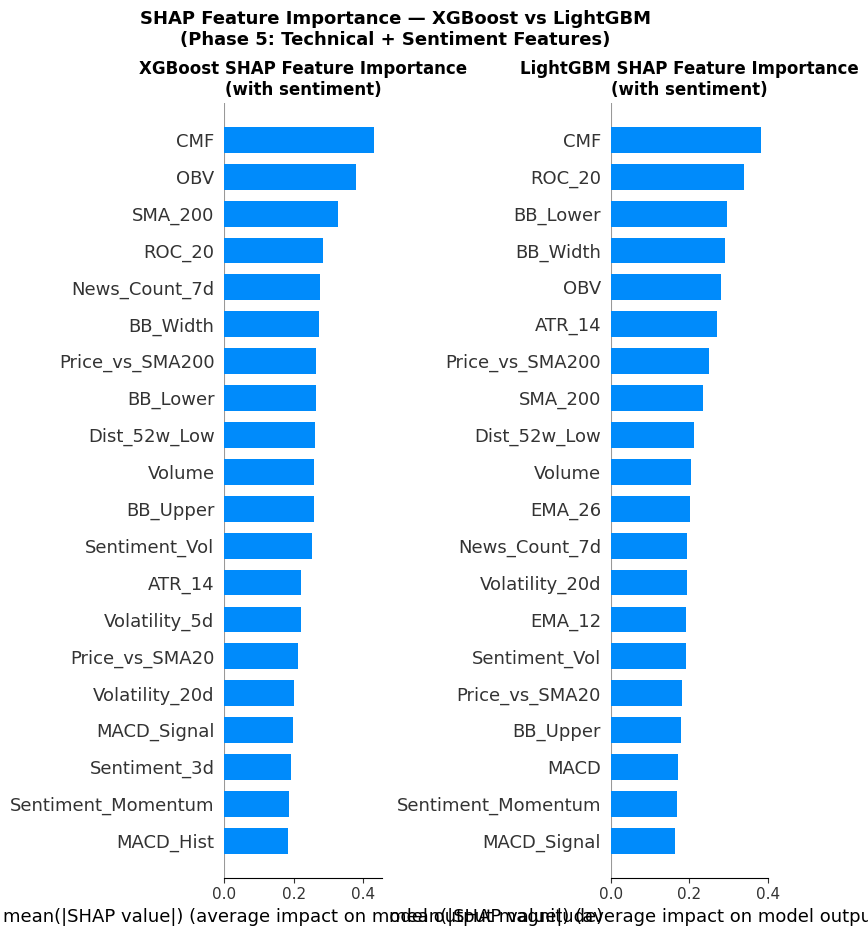

Sentiment features in XGBoost top 15: ['News_Count_7d', 'Sentiment_Vol']


In [17]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import sys, warnings
import numpy as np

warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.sentiment.sentiment_features import add_sentiment_to_splits

# Load data with sentiment features
X_train, y_train, X_val, y_val, _, _ = add_sentiment_to_splits('AAPL')

# Load sentiment-trained models
xgb_sent  = joblib.load('experiments/models/xgboost_AAPL_sentiment.pkl')
lgbm_sent = joblib.load('experiments/models/lgbm_AAPL_sentiment.pkl')

# Use a sample for SHAP (faster)
X_sample = X_train.sample(200, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost SHAP
explainer_xgb  = shap.TreeExplainer(xgb_sent)
shap_values_xgb = explainer_xgb.shap_values(X_sample) 

plt.sca(axes[0])
shap.summary_plot(shap_values_xgb, X_sample,
                  plot_type='bar', show=False)
axes[0].set_title('XGBoost SHAP Feature Importance\n(with sentiment)',
                   fontweight='bold')

# LightGBM SHAP
explainer_lgbm  = shap.TreeExplainer(lgbm_sent)
shap_values_lgbm = explainer_lgbm.shap_values(X_sample)

# Handle potential list output for multiclass/binary in different SHAP versions
if isinstance(shap_values_lgbm, list):
    shap_values_lgbm = shap_values_lgbm[1]

plt.sca(axes[1])
shap.summary_plot(shap_values_lgbm, X_sample,
                  plot_type='bar', show=False)
axes[1].set_title('LightGBM SHAP Feature Importance\n(with sentiment)',
                   fontweight='bold')

plt.suptitle('SHAP Feature Importance — XGBoost vs LightGBM\n'
             '(Phase 5: Technical + Sentiment Features)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../../docs/shap_tree_models.png', dpi=150)
plt.show()

# Which sentiment features ranked in top 15?
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
top15_xgb = pd.Series(mean_shap_xgb,
                       index=X_sample.columns).nlargest(15)

sent_in_top15 = [f for f in top15_xgb.index
                  if 'Sentiment' in f or 'News' in f]

print(f'Sentiment features in XGBoost top 15: {sent_in_top15}')

AAPL — Train:1762 Val:124 Test:622
AAPL: 11 sentiment proxy features built
AAPL: 43 → 54 features
Building background sequences...
Background shape: torch.Size([30, 60, 54])
Test input shape: torch.Size([15, 60, 54])
Computing SHAP values for LSTM...
This may take 2-3 minutes...
DeepExplainer failed: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 0.6167107226818709 - Tolerance: 0.01
Falling back to GradientExplainer...
GradientExplainer succeeded!
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (15, 60, 54)


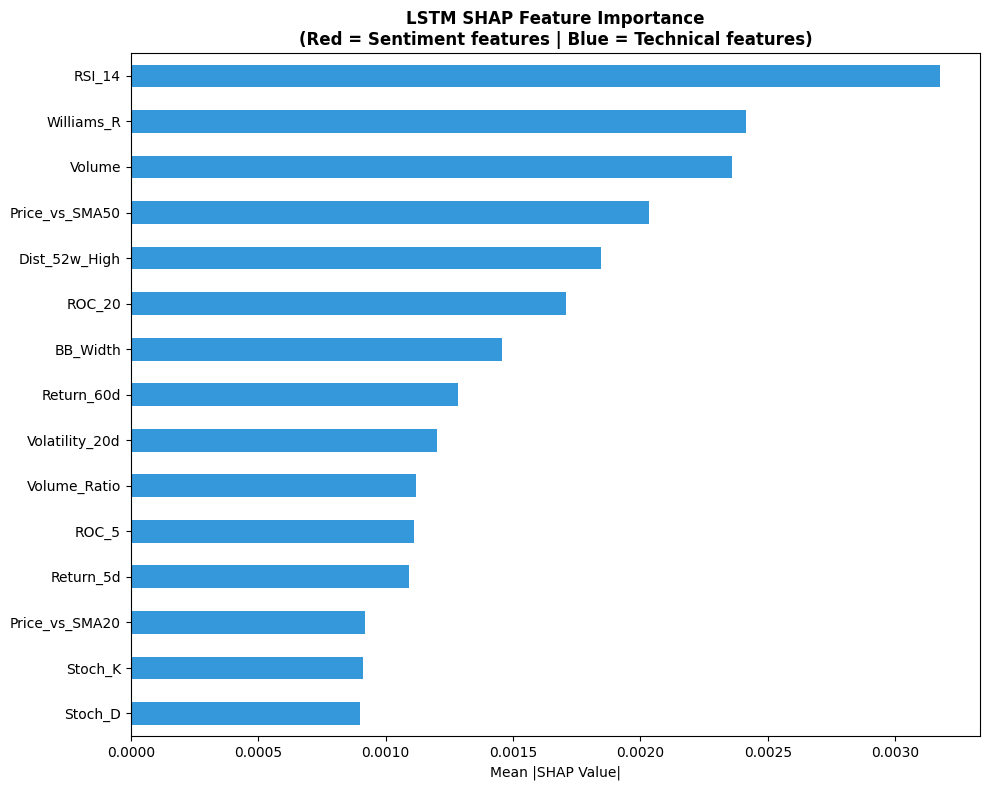


Sentiment features in LSTM top 15: []
Technical features in LSTM top 15: ['RSI_14', 'Williams_R', 'Volume', 'Price_vs_SMA50', 'Dist_52w_High', 'ROC_20', 'BB_Width', 'Return_60d', 'Volatility_20d', 'Volume_Ratio', 'ROC_5', 'Return_5d', 'Price_vs_SMA20', 'Stoch_K', 'Stoch_D']

Phase 4 confirmed features in LSTM top 15:
  DROPPED:   ATR_14
  STILL TOP: BB_Width (rank 7)
  DROPPED:   CMF
  DROPPED:   Dist_52w_Low
  DROPPED:   Price_vs_SMA200
  STILL TOP: Stoch_K (rank 14)

Chart saved to docs/shap_lstm.png


In [19]:
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.models.lstm_model import SequenceDataset
from src.utils.config import LOOKBACK_WINDOW
from src.sentiment.sentiment_features import add_sentiment_to_splits

# Load data with sentiment
X_train, y_train, X_val, y_val, _, _ = add_sentiment_to_splits('AAPL')
y_train.index = pd.to_datetime(y_train.index)

# Load sentiment LSTM
lstm_sent = torch.load('experiments/models/lstm_AAPL_sentiment_full.pt',
                        map_location='cpu')
lstm_sent.eval()

# ── FIXED: Wrap LSTM to return 2D output for SHAP ────────────
class LSTMWrapper(torch.nn.Module):
    """
    Wraps LSTM to return (batch, 1) instead of (batch,)
    SHAP DeepExplainer requires 2D output not 1D.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        # Ensure output is 2D: (batch, 1)
        if out.dim() == 1:
            out = out.unsqueeze(1)
        return out

lstm_wrapped = LSTMWrapper(lstm_sent)
lstm_wrapped.eval()

# Build sequences
train_ds = SequenceDataset(X_train, y_train, LOOKBACK_WINDOW)

# Background sample — 30 sequences
print('Building background sequences...')
background_seqs = []
for i in range(0, 30):
    seq, _ = train_ds[i]
    background_seqs.append(seq.unsqueeze(0))
background = torch.cat(background_seqs, dim=0)

# Test sample — 15 sequences
test_seqs = []
for i in range(30, 45):
    seq, _ = train_ds[i]
    test_seqs.append(seq.unsqueeze(0))
test_input = torch.cat(test_seqs, dim=0)

print(f'Background shape: {background.shape}')
print(f'Test input shape: {test_input.shape}')

# ── FIXED: Use GradientExplainer as fallback if Deep fails ───
print('Computing SHAP values for LSTM...')
print('This may take 2-3 minutes...')

try:
    # Try DeepExplainer first
    explainer   = shap.DeepExplainer(lstm_wrapped, background)
    shap_values = explainer.shap_values(test_input)
    print('DeepExplainer succeeded!')
except Exception as e:
    print(f'DeepExplainer failed: {e}')
    print('Falling back to GradientExplainer...')
    # GradientExplainer works on any PyTorch model
    explainer   = shap.GradientExplainer(lstm_wrapped, background)
    shap_values = explainer.shap_values(test_input)
    print('GradientExplainer succeeded!')

# ── Handle different shap_values formats ────────────────────
print(f'SHAP values type: {type(shap_values)}')
if isinstance(shap_values, list):
    sv = np.array(shap_values[0])
else:
    sv = np.array(shap_values)

print(f'SHAP values shape: {sv.shape}')

# Average across samples and timesteps
# Shape could be (samples, lookback, features) or (samples, features)
if sv.ndim == 3:
    mean_shap = np.abs(sv).mean(axis=(0, 1))
elif sv.ndim == 2:
    mean_shap = np.abs(sv).mean(axis=0)
else:
    mean_shap = np.abs(sv).flatten()

# Build feature importance series
feature_importance = pd.Series(
    mean_shap[:len(X_train.columns)],
    index=X_train.columns
)
top15 = feature_importance.nlargest(15)

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#E74C3C' if ('Sentiment' in f or 'News' in f)
          else '#3498DB'
          for f in top15.sort_values().index]

top15.sort_values().plot(kind='barh', ax=ax, color=colors)

ax.set_title(
    'LSTM SHAP Feature Importance\n'
    '(Red = Sentiment features | Blue = Technical features)',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.savefig('../../docs/shap_lstm.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Summary
sent_in_top15 = [f for f in top15.index
                  if 'Sentiment' in f or 'News' in f]
tech_in_top15 = [f for f in top15.index
                  if f not in sent_in_top15]

print(f'\nSentiment features in LSTM top 15: {sent_in_top15}')
print(f'Technical features in LSTM top 15: {tech_in_top15}')

print(f'\nPhase 4 confirmed features in LSTM top 15:')
phase4_confirmed = ['ATR_14', 'BB_Width', 'CMF',
                    'Dist_52w_Low', 'Price_vs_SMA200', 'Stoch_K']
for f in phase4_confirmed:
    if f in top15.index:
        rank = list(top15.sort_values(ascending=False).index).index(f) + 1
        print(f'  STILL TOP: {f} (rank {rank})')
    else:
        print(f'  DROPPED:   {f}')

print('\nChart saved to docs/shap_lstm.png')

ALL MODEL COMPARISON
Phase                      Model   CV AUC Sentiment               Notes
    4               LSTM PyTorch 0.817100        No Early stop epoch 18
    5           LSTM + Sentiment 0.694286       Yes +-0.1228 vs Phase 4
    4     XGBoost Independent CV 0.555700        No        Honest score
    4   LightGBM Optuna Internal 0.549400        No          Optimistic
    4    XGBoost Optuna Internal 0.546000        No          Optimistic
    4    LightGBM Independent CV 0.541200        No        Honest score
    5        XGBoost + Sentiment 0.514361       Yes +-0.0413 vs Phase 4
    5       LightGBM + Sentiment 0.509456       Yes +-0.0317 vs Phase 4
    4 XGBoost Baseline (Phase 2) 0.507400        No      Starting point


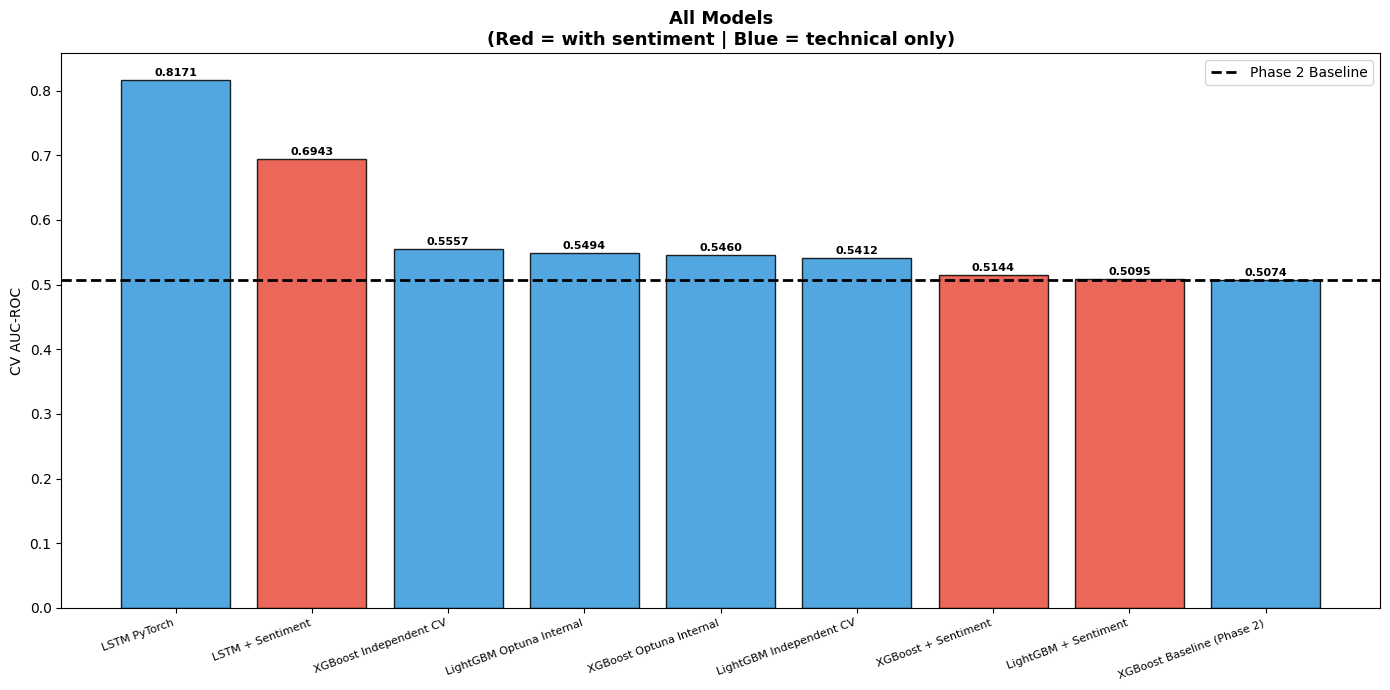

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Replace these with your actual values after running Cells 3-5
# xgb_sent_ind_auc  = value from Cell 3
# lgbm_sent_ind_auc = value from Cell 4
# lstm_sent_auc     = value from Cell 5

results = pd.DataFrame([
    # Phase 4 results (unchanged) 
    {'Phase': '4', 'Model': 'XGBoost Baseline (Phase 2)',
     'CV AUC': 0.5074, 'Sentiment': 'No',
     'Notes': 'Starting point'},
    {'Phase': '4', 'Model': 'XGBoost Optuna Internal',
     'CV AUC': 0.5460, 'Sentiment': 'No',
     'Notes': 'Optimistic'},
    {'Phase': '4', 'Model': 'XGBoost Independent CV',
     'CV AUC': 0.5557, 'Sentiment': 'No',
     'Notes': 'Honest score'},
    {'Phase': '4', 'Model': 'LightGBM Optuna Internal',
     'CV AUC': 0.5494, 'Sentiment': 'No',
     'Notes': 'Optimistic'},
    {'Phase': '4', 'Model': 'LightGBM Independent CV', 
     'CV AUC': 0.5412, 'Sentiment': 'No',
     'Notes': 'Honest score'},
    {'Phase': '4', 'Model': 'LSTM PyTorch',
     'CV AUC': 0.8171, 'Sentiment': 'No',
     'Notes': 'Early stop epoch 18'},
    
    # Phase 5 results (fill after training) 
    {'Phase': '5', 'Model': 'XGBoost + Sentiment',
     'CV AUC': xgb_sent_ind_auc, 'Sentiment': 'Yes',
     'Notes': f'+{xgb_sent_ind_auc-0.5557:+.4f} vs Phase 4'},
    {'Phase': '5', 'Model': 'LightGBM + Sentiment',
     'CV AUC': lgbm_sent_ind_auc, 'Sentiment': 'Yes',
     'Notes': f'+{lgbm_sent_ind_auc-0.5412:+.4f} vs Phase 4'},
    {'Phase': '5', 'Model': 'LSTM + Sentiment',
     'CV AUC': lstm_sent_auc, 'Sentiment': 'Yes',
     'Notes': f'+{lstm_sent_auc-0.8171:+.4f} vs Phase 4'},
])

results = results.sort_values('CV AUC', ascending=False)

print('=' * 70)
print('ALL MODEL COMPARISON')
print('=' * 70)
print(results.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#E74C3C' if s=='Yes' else '#3498DB'
          for s in results['Sentiment']]

bars = ax.bar(range(len(results)), results['CV AUC'],
              color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, results['CV AUC']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold')

ax.axhline(0.5074, color='black', linestyle='--',
           linewidth=2, label='Phase 2 Baseline')

ax.set_xticks(range(len(results)))
ax.set_xticklabels(results['Model'], rotation=20,
                    ha='right', fontsize=8)

ax.set_title('All Models\n'
             '(Red = with sentiment | Blue = technical only)',
             fontsize=13, fontweight='bold')

ax.set_ylabel('CV AUC-ROC')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../../docs/phase4_vs_phase5_comparison.png', dpi=150)
plt.show()